In [ ]:
# Redefine the project root directory and add it to the system path
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [1]:
# Test: Data Loader's Fred Data
from src.data_loader import fred
series = fred.get_series("DGS10")
print(series.tail())

2026-06-25    4.40
2026-06-26    4.38
2026-06-29    4.38
2026-06-30    4.44
2026-07-01    4.48
dtype: float64


In [3]:
# Test: Data Loader's Yield Curve History
from src.data_loader import get_yield_curve_history
curve_df = get_yield_curve_history()
curve_df.tail()

,1M,3M,6M,1Y,2Y,5Y,10Y,30Y
date,,,,,,,,
2026-06-25,3.70,3.84,3.95,3.96,4.09,4.15,4.40,4.86
2026-06-26,3.70,3.83,3.94,3.94,4.07,4.12,4.38,4.87
2026-06-29,3.71,3.87,4.00,3.97,4.10,4.14,4.38,4.86
2026-06-30,3.70,3.87,4.01,3.98,4.14,4.19,4.44,4.91
2026-07-01,3.67,3.85,4.00,4.00,4.17,4.24,4.48,4.97


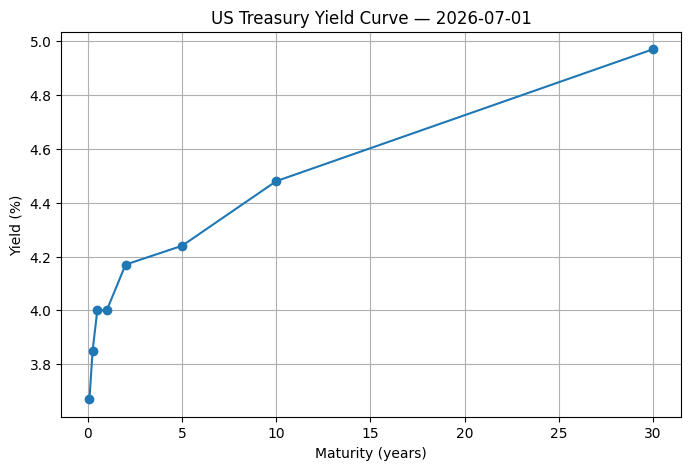

In [4]:
import matplotlib.pyplot as plt

latest = curve_df.dropna().iloc[-1]
maturities_years = [1/12, 3/12, 6/12, 1, 2, 5, 10, 30]

plt.figure(figsize=(8,5))
plt.plot(maturities_years, latest.values, marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title(f"US Treasury Yield Curve — {latest.name.date()}")
plt.grid(True)
plt.show()

In [2]:
#Test: Data Loader's Bond ETF Prices
from src.data_loader import get_bond_etf_prices
etf_df = get_bond_etf_prices()
etf_df.tail()

[*********************100%***********************]  3 of 3 completed


Ticker,HYG,LQD,TLT
Date,,,
2026-06-26,79.461647,109.116501,87.038544
2026-06-29,79.640816,109.315796,87.128204
2026-06-30,79.600998,108.688004,86.101997
2026-07-01,79.589996,108.459999,85.519997
2026-07-02,79.709999,108.639999,85.510002


In [3]:
# Test: Bond's mathematical calculations
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.bond import Bond
# Test 1: par bond — price should equal face value when coupon rate == ytm
b = Bond(face_value=100, coupon_rate=0.07, years_to_maturity=3, freq=1)
print(b.price(0.07))  # expect ~100.0

# Test 2: zero-coupon bond — Macaulay duration should equal maturity exactly
zero = Bond(face_value=100, coupon_rate=0.0, years_to_maturity=5, freq=1)
print(zero.macaulay_duration(0.05))  # expect ~5.0

# Test 3: YTM solver round-trip
price_at_5pct = b.price(0.05)
print(b.ytm(price_at_5pct))  # expect ~0.05

100.0
5.0
0.05
